# Entrance Exam Classification Project

## Imports

In [2]:
from scipy.io import arff
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## Data Wrangling

### Load ARFF into a DataFrame

In [3]:
# Load the ARFF file and convert it to a DataFrame (of bytes)
data, meta = arff.loadarff("../data/raw/CEE_DATA.arff")
df = pd.DataFrame(data)

# Decode byte strings to regular strings for all columns
for column in df.columns:
    if df[column].dtype == 'object':  # Check if the column is of type object (bytes)
        df[column] = df[column].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# Remove whitespace and uppercasing from column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# Rename a few columns for clarity
df.rename(columns={
    'class_ten_education': 'class_10_education',
    'twelve_education': 'class_12_education',
    'class__x_percentage': 'class_10_percentage',
    'class_xii_percentage': 'class_12_percentage'
}, inplace=True)

### Examining the data structure

In [4]:
print('First five rows of DataFrame: \n', df.head(), '\n')
print('Shape of DataFrame: ', df.shape, '\n')

First five rows of DataFrame: 
   performance gender    caste coaching time class_10_education  \
0   Excellent   male  General       NO  ONE               SEBA   
1   Excellent   male      OBC       WA  TWO               SEBA   
2   Excellent   male      OBC       OA  TWO             OTHERS   
3   Excellent   male  General       WA  ONE               SEBA   
4   Excellent   male  General       OA  TWO               SEBA   

  class_12_education   medium class_10_percentage class_12_percentage  \
0              AHSEC  ENGLISH           Excellent           Excellent   
1              AHSEC   OTHERS           Excellent           Excellent   
2               CBSE  ENGLISH           Excellent           Excellent   
3              AHSEC   OTHERS           Excellent           Excellent   
4               CBSE  ENGLISH           Excellent           Excellent   

  father_occupation mother_occupation  
0            DOCTOR            OTHERS  
1    SCHOOL_TEACHER        HOUSE_WIFE  
2          B

#### Check for missing values

In [5]:
print('There are no non-null values: ')
print(df.info(), '\n')

There are no non-null values: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   performance          666 non-null    object
 1   gender               666 non-null    object
 2   caste                666 non-null    object
 3   coaching             666 non-null    object
 4   time                 666 non-null    object
 5   class_10_education   666 non-null    object
 6   class_12_education   666 non-null    object
 7   medium               666 non-null    object
 8   class_10_percentage  666 non-null    object
 9   class_12_percentage  666 non-null    object
 10  father_occupation    666 non-null    object
 11  mother_occupation    666 non-null    object
dtypes: object(12)
memory usage: 62.6+ KB
None 



#### Check for implicit missing values

In [6]:
print('There are no implicit missing values: \n', df.apply(lambda c: c.str.upper().isin(["NA", "N/A", "?", ""]).sum()), '\n')

There are no implicit missing values: 
 performance            0
gender                 0
caste                  0
coaching               0
time                   0
class_10_education     0
class_12_education     0
medium                 0
class_10_percentage    0
class_12_percentage    0
father_occupation      0
mother_occupation      0
dtype: int64 



#### Check feature counts

Target 'performance' has 4 classes; Excellent is the smallest of them.
Several predictors (coaching, medium) are imbalanced.
All input features are categorical.

In [7]:
print(df["performance"].value_counts())
print(df["performance"].value_counts(normalize=True))
print(df["gender"].value_counts())
print(df["caste"].value_counts())
print(df["coaching"].value_counts())
print(df["time"].value_counts())
print(df["class_10_education"].value_counts())
print(df["class_12_education"].value_counts())
print(df["class_10_percentage"].value_counts())
print(df["class_12_percentage"].value_counts())
print(df["medium"].value_counts())
print(df["father_occupation"].value_counts())
print(df["mother_occupation"].value_counts())

performance
Good         210
Vg           198
Average      157
Excellent    101
Name: count, dtype: int64
performance
Good         0.315315
Vg           0.297297
Average      0.235736
Excellent    0.151652
Name: proportion, dtype: float64
gender
male      355
female    311
Name: count, dtype: int64
caste
General    329
OBC        162
ST         108
SC          67
Name: count, dtype: int64
coaching
WA    449
NO    150
OA     67
Name: count, dtype: int64
time
TWO      368
ONE      199
THREE     86
FOUR      11
FIVE       1
SEVEN      1
Name: count, dtype: int64
class_10_education
SEBA      396
CBSE      249
OTHERS     21
Name: count, dtype: int64
class_12_education
AHSEC     368
CBSE      290
OTHERS      8
Name: count, dtype: int64
class_10_percentage
Excellent    511
Vg           101
Good          41
Average       13
Name: count, dtype: int64
class_12_percentage
Excellent    398
Vg           181
Good          75
Average       12
Name: count, dtype: int64
medium
ENGLISH     536
OTHERS   

### Create the Target and Set Aside a Test Set

In [8]:
X = df.drop(columns=["performance"])
y = df["performance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Visualize Distribution

The 'time' feature has two singleton classes that may need to be excluded.

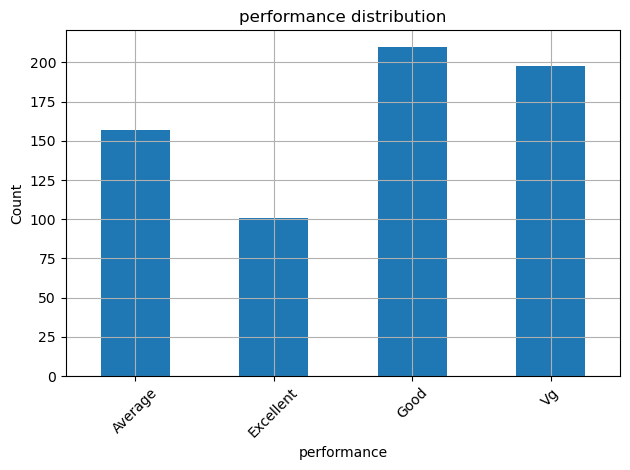

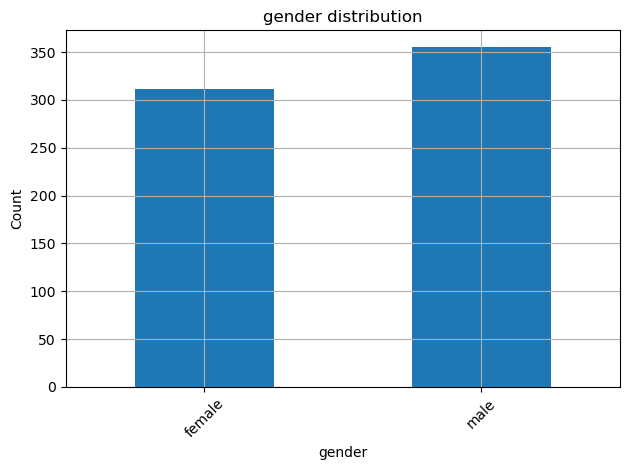

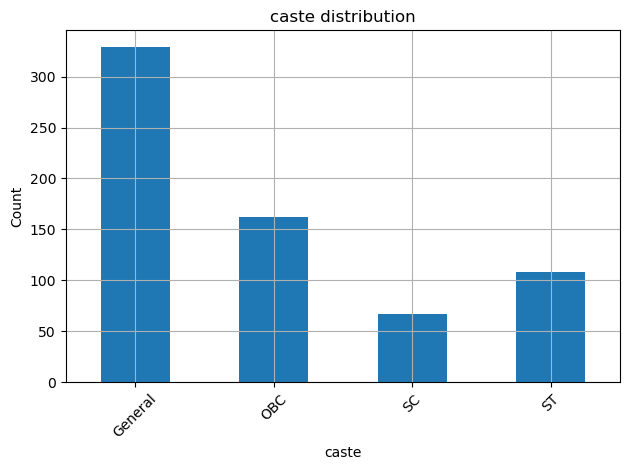

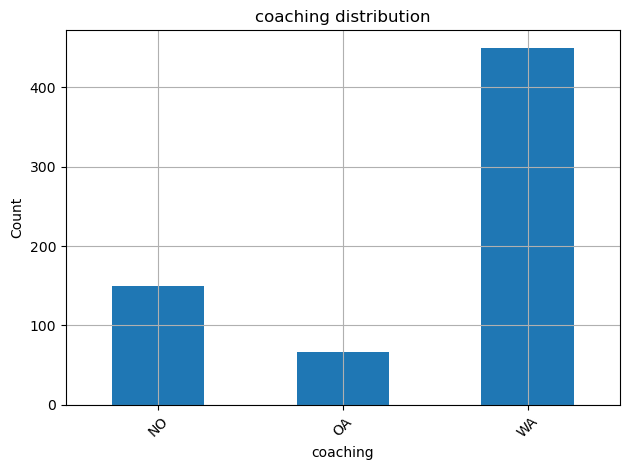

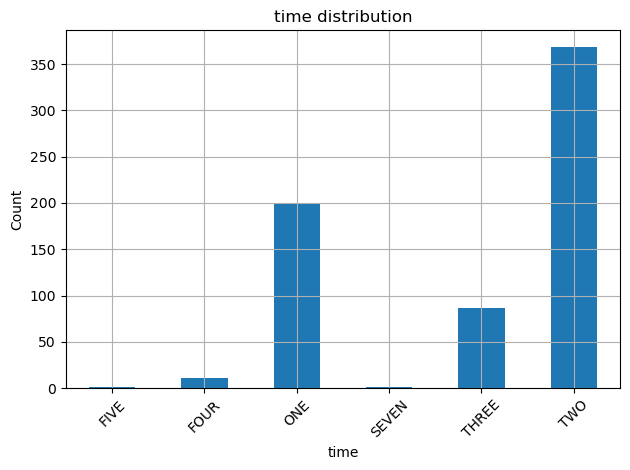

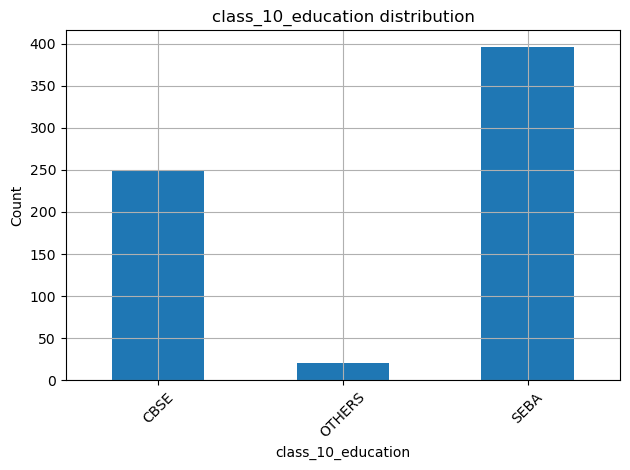

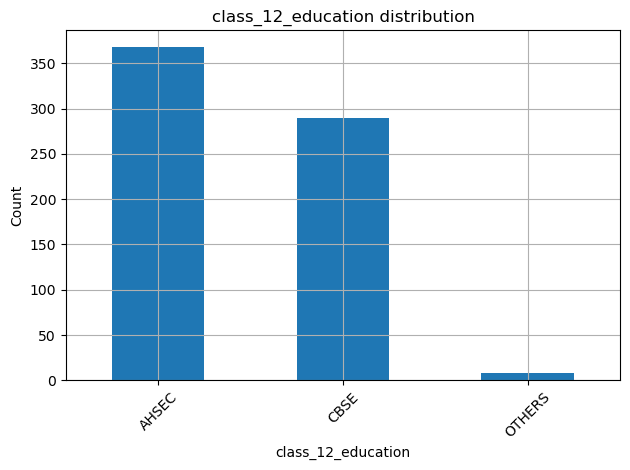

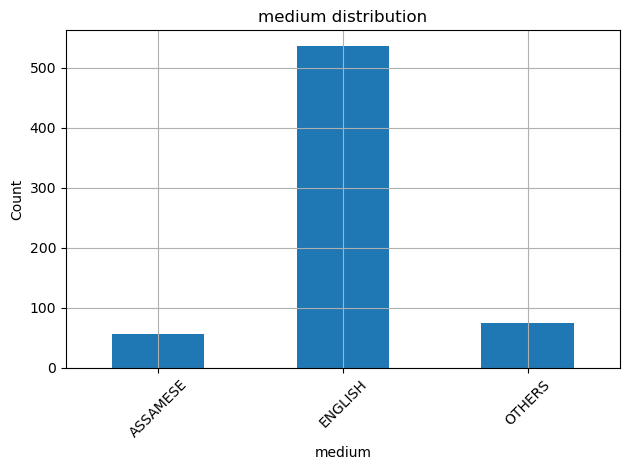

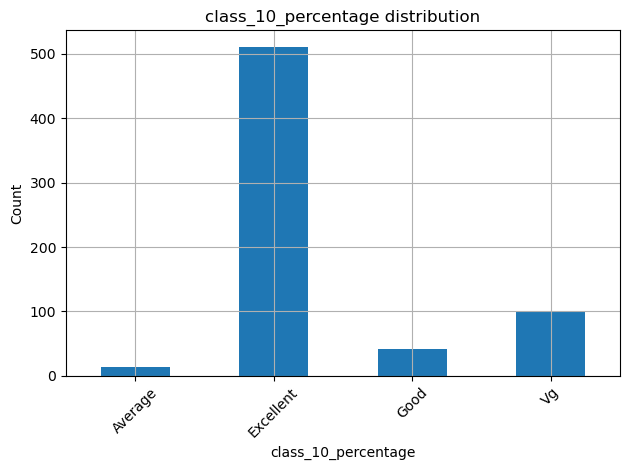

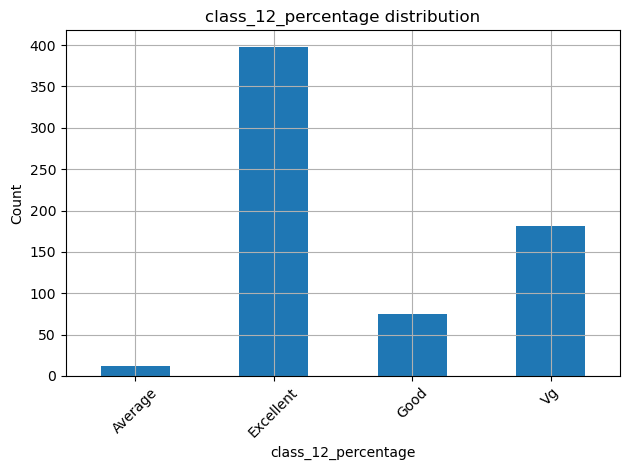

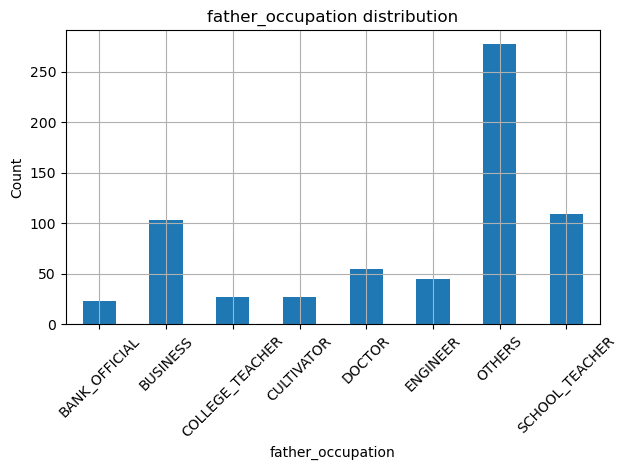

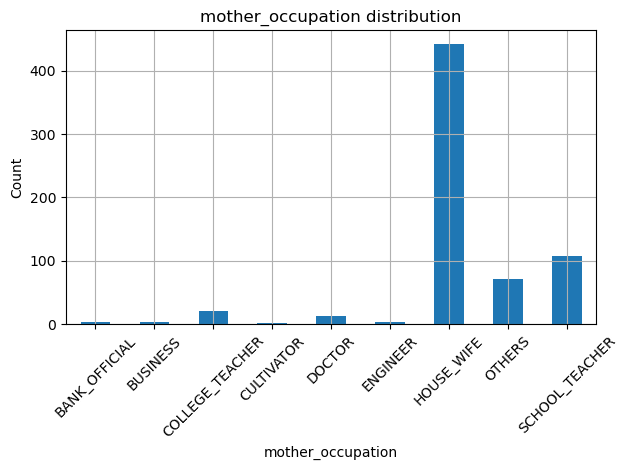

In [9]:
for col in df.columns:
    counts = df[col].value_counts()
    counts = counts.sort_index()

    counts.plot.bar(rot=45, grid=True)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f'{col} distribution')
    plt.tight_layout()
    plt.show()

### Look for Relationships and Correlations

Here we find the conditional distributions for every value of every input feature.
The conditional distribution is the fraction of a group that falls into a certain outcome class.
For example, in row 1: 24.7% of females had Average performance. 11.9% were in Excellent, 32.2% in Good, and 31.2% Vg (Very good). Some features (caste) are associated with big shifts in performance.

In [10]:
target = "performance"
features = [c for c in df.columns if c != target]

for c in features:
    print("\n==", c, "==")
    print(pd.crosstab(df[c], df[target], normalize="index"))


== gender ==
performance   Average  Excellent      Good        Vg
gender                                              
female       0.247588   0.118971  0.321543  0.311897
male         0.225352   0.180282  0.309859  0.284507

== caste ==
performance   Average  Excellent      Good        Vg
caste                                               
General      0.000000   0.252280  0.337386  0.410334
OBC          0.154321   0.092593  0.450617  0.302469
SC           0.462687   0.044776  0.313433  0.179104
ST           0.935185   0.000000  0.046296  0.018519

== coaching ==
performance   Average  Excellent      Good        Vg
coaching                                            
NO           0.266667   0.133333  0.346667  0.253333
OA           0.134328   0.358209  0.298507  0.208955
WA           0.240535   0.126949  0.307350  0.325167

== time ==
performance   Average  Excellent      Good        Vg
time                                                
FIVE         0.000000   0.000000  1.000000  

### Clean Data

The feature 'time' has two classes with a single record each, producing misleading results in the conditional distributions. It's also unclear what the feature actually records, and the dataset's publisher provides no description of the feature. For all these reasons, we choose to drop this feature.

In [11]:
X_train = X_train.drop(columns=['time'])
X_test = X_test.drop(columns=['time'])
df = df.drop(columns=['time'])

df.to_csv("../data/processed/CEE_DATA.csv", index=False)

## Feature Transformation

### Encode the Target Variable

In [12]:
target_mapping = {'Average': 0, 'Good': 1, 'Vg': 2, 'Excellent': 3}
y_train_mapped = y_train.map(target_mapping)

## Baseline Models

### Define the Preprocessing Pipeline

In [13]:
percentage_order = ['Average', 'Good', 'Vg', 'Excellent']

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[percentage_order, percentage_order]),
         ['class_10_percentage', 'class_12_percentage']),
        
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         ['gender', 'caste', 'coaching', 'medium', 'father_occupation', 'mother_occupation', 'class_10_education', 'class_12_education'])
    ])

### Build Baseline Model Pipelines

In [14]:
knn_pipe = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=chi2, k=15)),
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

log_pipe = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=chi2, k=15)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

gnb_pipe = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=chi2, k=15)),
    ('model', GaussianNB())
])

### Initial Evaluation via Cross-Validation

Logistic Regression performed best at 52% accuracy (versus 25% for random chance).

In [15]:
models = [('kNN', knn_pipe), ('Logistic Regression', log_pipe), ('Gaussian NB', gnb_pipe)]

for name, pipeline in models:
    results = cross_validate(pipeline, X_train, y_train_mapped, cv=10, scoring='accuracy')

    mean_acc = results['test_score'].mean()
    std_acc = results['test_score'].std()

    print(f"{name}: Mean Accuracy: {mean_acc:.4f}, (+/- {std_acc:.4f})")

kNN: Mean Accuracy: 0.4624, (+/- 0.0604)
Logistic Regression: Mean Accuracy: 0.5224, (+/- 0.0761)
Gaussian NB: Mean Accuracy: 0.3384, (+/- 0.0147)


## Hyperparameter Tuning

We test 52 versions of our best baseline model. Our best model is logistic regression with a regularization strength of 1 and dropping all but the 13 best features.

In [16]:
param_grid = [
    {
        'select__k': [5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29],
        'model__C': [0.01, 0.1, 1, 10]
    }
]

grid_search = GridSearchCV(log_pipe, param_grid, cv=10, scoring='accuracy', verbose=1)

grid_search.fit(X_train, y_train_mapped)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Fitting 10 folds for each of 52 candidates, totalling 520 fits
Best parameters: {'model__C': 1, 'select__k': 13}
Best CV accuracy: 0.5374


## Final Evaluation

### Final Evaluation on the Test Set

In [17]:
y_test_mapped = y_test.map(target_mapping)

final_model = grid_search.best_estimator_

final_predictions = final_model.predict(X_test)

final_accuracy = accuracy_score(y_test_mapped, final_predictions)
print(f"Final test set accuracy: {final_accuracy:.4f}")

Final test set accuracy: 0.5373


### Confusion Matrix

The confusion matrix shows that while our model does misclassify ~46% of instances, it usually misclassifies them into adjacent categories - for example, it didn't misclassify any Excellent instances as Average.

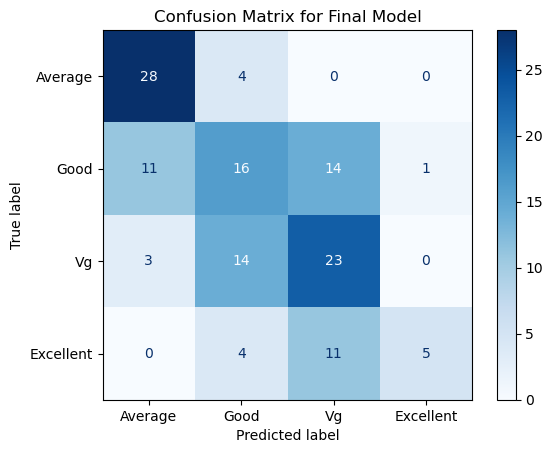

In [18]:
cm = confusion_matrix(y_test_mapped, final_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_mapping.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Final Model")
plt.show()

### Classification Report

The model handles average well. It correctly identifies 88% of average students. This is partly because the model is over-predicting Average. Excellent has the opposite problem - the model only catches 1 in 4 Excellent students. Good is the weakest class - both precision and recall are low.

In [19]:
print("Classification Report: ")
print(classification_report(y_test_mapped, final_predictions, target_names=target_mapping.keys()))

Classification Report: 
              precision    recall  f1-score   support

     Average       0.67      0.88      0.76        32
        Good       0.42      0.38      0.40        42
          Vg       0.48      0.57      0.52        40
   Excellent       0.83      0.25      0.38        20

    accuracy                           0.54       134
   macro avg       0.60      0.52      0.52       134
weighted avg       0.56      0.54      0.52       134



### Feature Importance

The strongest predictor of excellent performance is being from the General caste category. The next strongest predictors are private coaching, studying in a language other than English or Assamese, and having a college teacher for a parent.

In [20]:
feature_mask = final_model.named_steps['select'].get_support()
all_feature_names = final_model.named_steps['prep'].get_feature_names_out()
feature_names = all_feature_names[feature_mask]

excellent_coefs = final_model.named_steps['model'].coef_[3]

feature_importance = sorted(zip(excellent_coefs, feature_names), reverse=True)
print("\nTop features for predicting 'Excellent':")
for score, name in feature_importance[:5]:
    print(f"{name}: {score:.4f}")


Top features for predicting 'Excellent':
nom__caste_General: 0.7317
nom__coaching_OA: 0.3323
nom__medium_OTHERS: 0.2627
nom__father_occupation_COLLEGE_TEACHER: 0.1972
nom__mother_occupation_COLLEGE_TEACHER: 0.1937


## Save the Final Model

In [21]:
import joblib

joblib.dump(final_model, 'final_model.joblib')
print("Model saved as final_model.joblib")

Model saved as final_model.joblib


# Auction Verification Regression Project

## Imports

In [54]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Data Wrangling

### Load CSV into a DataFrame

In [38]:
df_reg = pd.read_csv("../data/raw/data.csv")

# Drop the classification target - we are only predicting price
df_reg = df_reg.drop(columns=["verification.result"])

print(df_reg.head())

   process.b1.capacity  process.b2.capacity  process.b3.capacity  \
0                    0                    0                    2   
1                    0                    0                    2   
2                    0                    0                    2   
3                    0                    0                    2   
4                    0                    0                    2   

   process.b4.capacity  property.price  property.product  property.winner  \
0                    1              59                 1                0   
1                    1              59                 2                0   
2                    1              59                 4                0   
3                    1              59                 6                0   
4                    1              60                 1                0   

   verification.time  
0         163.316667  
1         200.860000  
2         154.888889  
3         108.640000  
4          85

### Examining the Data Structure

In [39]:
print('First five rows of DataFrame: \n', df_reg.head(), '\n')
print('Shape of DataFrame: ', df_reg.shape, '\n')

First five rows of DataFrame: 
    process.b1.capacity  process.b2.capacity  process.b3.capacity  \
0                    0                    0                    2   
1                    0                    0                    2   
2                    0                    0                    2   
3                    0                    0                    2   
4                    0                    0                    2   

   process.b4.capacity  property.price  property.product  property.winner  \
0                    1              59                 1                0   
1                    1              59                 2                0   
2                    1              59                 4                0   
3                    1              59                 6                0   
4                    1              60                 1                0   

   verification.time  
0         163.316667  
1         200.860000  
2         154.888889  
3   

### Check Feature Distributions

In [40]:
print(df_reg.describe(), '\n')

       process.b1.capacity  process.b2.capacity  process.b3.capacity  \
count          2043.000000          2043.000000          2043.000000   
mean              1.000000             2.093979             1.883994   
std               0.816696             0.811269             0.320310   
min               0.000000             0.000000             1.000000   
25%               0.000000             1.000000             2.000000   
50%               1.000000             2.000000             2.000000   
75%               2.000000             3.000000             2.000000   
max               2.000000             3.000000             2.000000   

       process.b4.capacity  property.price  property.product  property.winner  \
count          2043.000000     2043.000000       2043.000000      2043.000000   
mean              0.587861       71.473324          3.252080         0.455213   
std               0.492340        8.048740          1.804225         1.062828   
min               0.000000 

The target verification.time is heavily right-skewed. The max (44,130s) is far above the mean (7,337s) which is far above the median (1,317s).

### Create the Target and Set Aside a Test Set

In [41]:
X_reg = df_reg.drop(columns=['verification.time'])
y_reg = df_reg['verification.time']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42, stratify=X_reg['property.winner'])

Below you can see that property.winner is massively inbalanced. For that reason we stratify our train_test_split() on property.winner.

### Visualize Distribution

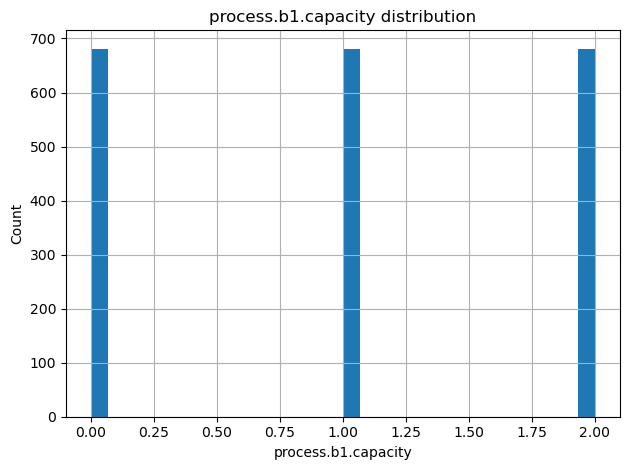

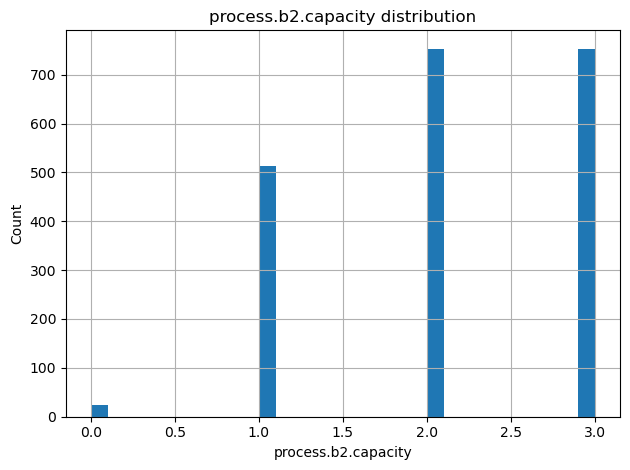

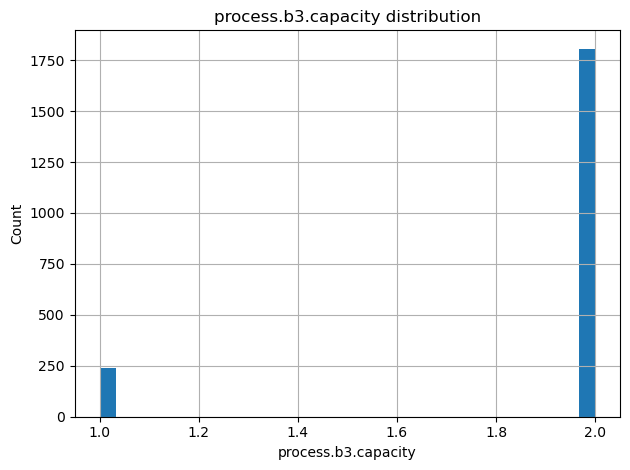

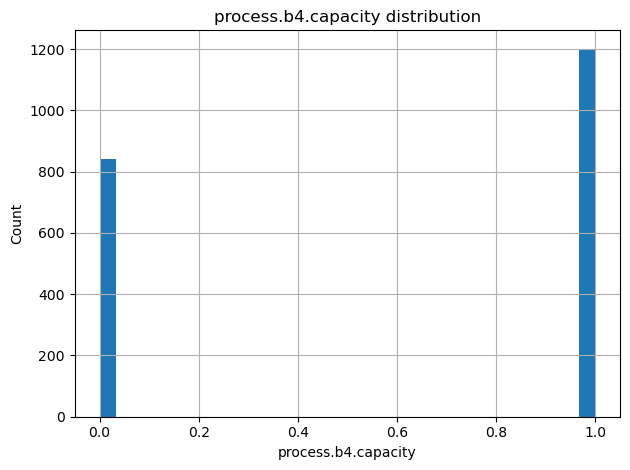

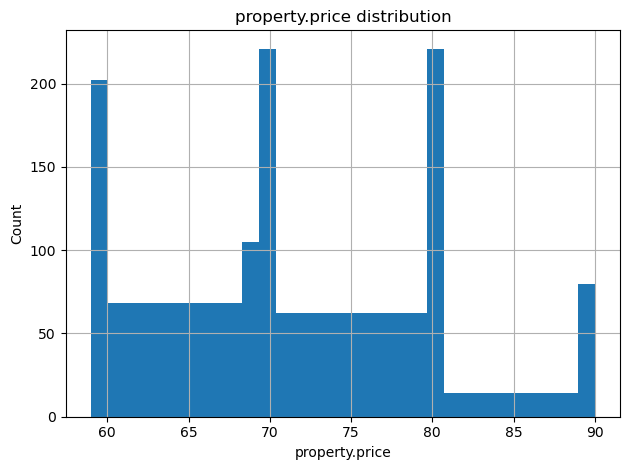

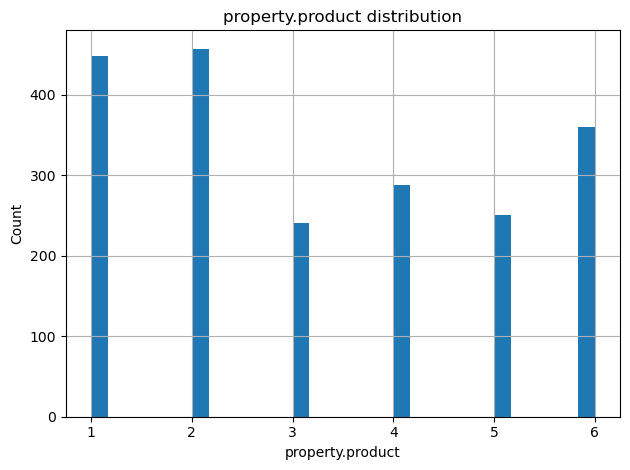

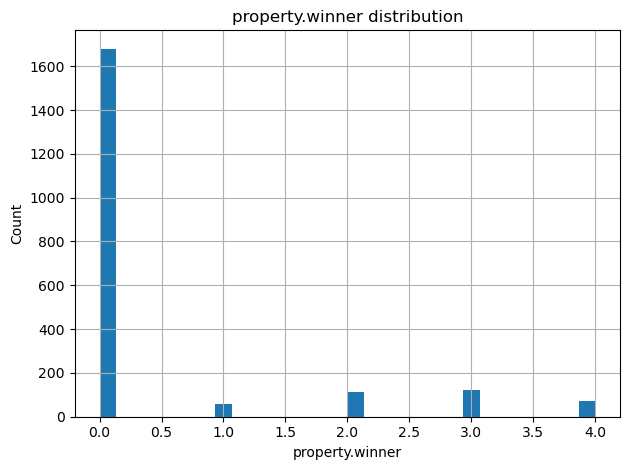

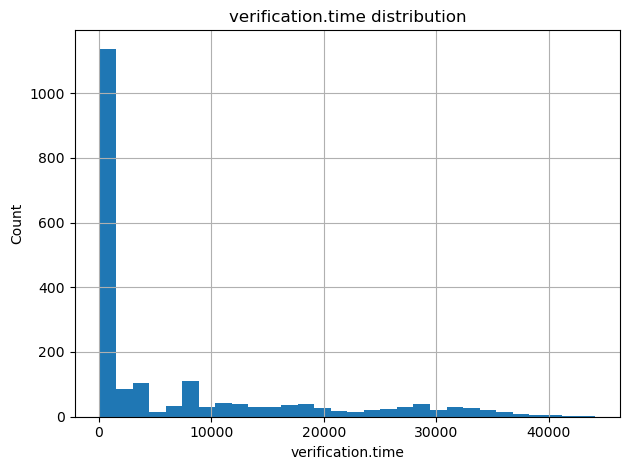

In [42]:
for col in df_reg.columns:
    plt.figure()
    df_reg[col].hist(bins=30, grid=True)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'{col} distribution')
    plt.tight_layout()
    plt.show()

### Log-Transform the Target

verification.time is heavily right-skewed, so we log-transform the target to compress the tail. This is required for Linear Regression's normality assumption and benefits the other models as well.

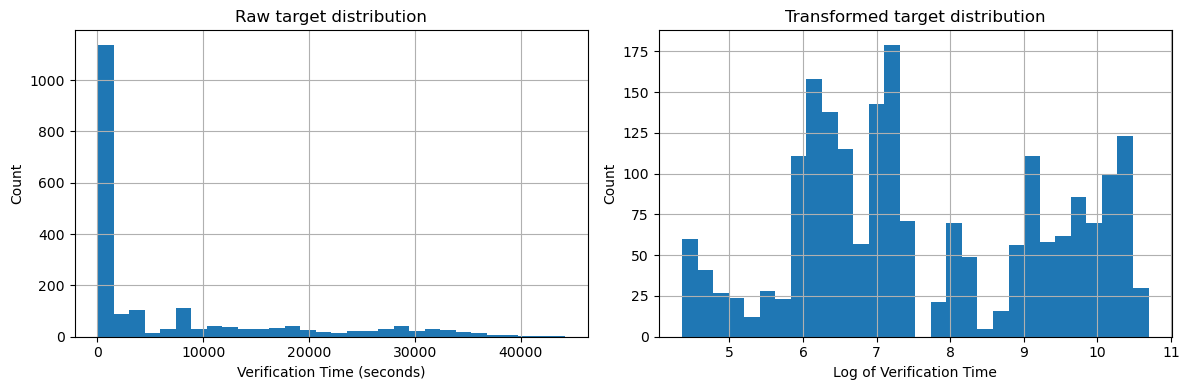

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_reg['verification.time'].hist(bins=30, grid=True, ax=axes[0])
axes[0].set_xlabel('Verification Time (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw target distribution')

np.log(df_reg['verification.time']).hist(bins=30, grid=True, ax=axes[1])
axes[1].set_xlabel('Log of Verification Time')
axes[1].set_ylabel('Count')
axes[1].set_title('Transformed target distribution')

plt.tight_layout()
plt.show()

### Look for Relationships and Correlations

Here we use Pearson correlation to check how strongly each feature is linearly associated with the target. We correlate against the log-transformed target, since that is what our models will effectively be fitting.

Correlation with log(verification.time): 
 process.b1.capacity    0.533449
process.b3.capacity    0.347780
property.product      -0.319759
property.winner       -0.217987
property.price         0.172691
process.b4.capacity    0.089885
process.b2.capacity    0.088945
Name: log_time, dtype: float64 



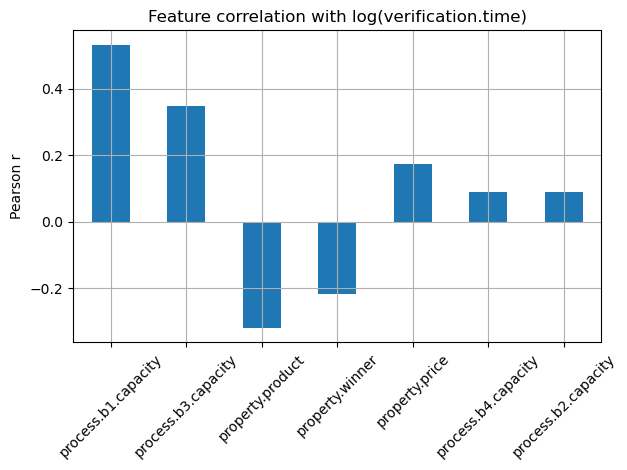

In [44]:
df_reg_corr = df_reg.copy()
df_reg_corr['log_time'] = np.log(df_reg['verification.time'])

corr = df_reg_corr.corr()['log_time'].drop(['verification.time', 'log_time']).sort_values(key=abs, ascending=False)
print('Correlation with log(verification.time): \n', corr, '\n')

corr.plot.bar(rot=45, grid=True)
plt.ylabel('Pearson r')
plt.title('Feature correlation with log(verification.time)')
plt.tight_layout()
plt.show()

### Clean Data

No columns are dropped. We save the processed file for reproducibility.

In [45]:
df_reg.to_csv("../data/processed/Auction_Verification.csv", index=False)

## Baseline Models

### Define the Preprocessing Pipeline

In [46]:
reg_preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), list(X_reg.columns))
    ]
)

### Build Baseline Model Pipelines

We wrap each model in a TransformedTargetRegressor with a log transform on the target. The model will train on log(verification.time) internally, and predictions are converted back to seconds before being returned.

In [48]:
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)

knn_reg_pipe = Pipeline([
    ('prep', reg_preprocessor),
    ('select', SelectKBest(score_func=f_regression, k=5)),
    ('model', TransformedTargetRegressor(
        KNeighborsRegressor(n_neighbors=5),
        transformer=log_transformer
    ))
])

lr_pipe = Pipeline([
    ('prep', reg_preprocessor),
    ('select', SelectKBest(score_func=f_regression, k=5)),
    ('model', TransformedTargetRegressor(
        LinearRegression(),
        transformer=log_transformer
    ))
])

svr_pipe = Pipeline([
    ('prep', reg_preprocessor),
    ('select', SelectKBest(score_func=f_regression, k=5)),
    ('model', TransformedTargetRegressor(
        SVR(kernel='rbf'),
        transformer=log_transformer
    ))
])

rf_pipe = Pipeline([
    ('prep', reg_preprocessor),
    ('model', TransformedTargetRegressor(
        RandomForestRegressor(n_estimators=100, random_state=42),
        transformer=log_transformer
    ))
])

### Initial Evaluation via Cross-Validation

In [50]:
reg_models = [('kNN', knn_reg_pipe), ('Linear Regression', lr_pipe), ('SVR', svr_pipe), ('Random Forest', rf_pipe)]

for name, pipeline in reg_models:
    results = cross_validate(
        pipeline, X_reg_train, y_reg_train,
        cv=10,
        scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'],
        return_train_score=True
    )

    train_rmse = np.sqrt(-results['train_neg_mean_squared_error']).mean()
    val_rmse = np.sqrt(-results['test_neg_mean_squared_error']).mean()
    mean_r2 = results['test_r2'].mean()
    mean_mae = -results['test_neg_mean_absolute_error'].mean()

    print(f"{name}: Train RMSE: {train_rmse: .2f}s | Val RMSE: {val_rmse: .2f}s | R^2: {mean_r2: .4f} | MAE: {mean_mae: .2f}s")
    if train_rmse < val_rmse * 0.8:
        print(f" Warning: {name} may be overfitting.")

kNN: Train RMSE:  2900.27s | Val RMSE:  3796.40s | R^2:  0.8533 | MAE:  1750.35s
Linear Regression: Train RMSE:  9290.47s | Val RMSE:  9272.07s | R^2:  0.1460 | MAE:  5109.11s
SVR: Train RMSE:  7051.89s | Val RMSE:  7141.95s | R^2:  0.4927 | MAE:  3675.63s
Random Forest: Train RMSE:  344.25s | Val RMSE:  902.95s | R^2:  0.9915 | MAE:  408.02s


Models ordered by the coefficient of determination: Random Forest (99%, great), kNN, SVR, Linear Regression (the relationship doesn't appear to be linear, no point tuning)

## Hyperparameter Tuning

In [53]:
rf_param_grid = [
    {
        'model__regressor__n_estimators': [100, 200, 500],
        'model__regressor__max_depth': [5, 10, 20, None],
        'model__regressor__min_samples_leaf': [1, 5, 10],
    }
]

reg_grid_search = GridSearchCV(rf_pipe, rf_param_grid, cv=10, scoring='r2', return_train_score=True, verbose=1)

reg_grid_search.fit(X_reg_train, y_reg_train)

results_df = pd.DataFrame(reg_grid_search.cv_results_)
results_df['gap'] = results_df['mean_train_score'] - results_df['mean_test_score']
print(results_df[['params', 'mean_train_score', 'mean_test_score', 'gap']].sort_values('mean_test_score', ascending=False).head(10))

Fitting 10 folds for each of 36 candidates, totalling 360 fits
                                               params  mean_train_score  \
29  {'model__regressor__max_depth': None, 'model__...          0.998900   
20  {'model__regressor__max_depth': 20, 'model__re...          0.998900   
28  {'model__regressor__max_depth': None, 'model__...          0.998857   
19  {'model__regressor__max_depth': 20, 'model__re...          0.998857   
27  {'model__regressor__max_depth': None, 'model__...          0.998829   
18  {'model__regressor__max_depth': 20, 'model__re...          0.998829   
11  {'model__regressor__max_depth': 10, 'model__re...          0.995729   
10  {'model__regressor__max_depth': 10, 'model__re...          0.995676   
9   {'model__regressor__max_depth': 10, 'model__re...          0.995606   
23  {'model__regressor__max_depth': 20, 'model__re...          0.984173   

    mean_test_score       gap  
29         0.991681  0.007219  
20         0.991681  0.007219  
28         0.99

## Final Evaluation

In [55]:
reg_final_model = reg_grid_search.best_estimator_

y_reg_pred = reg_final_model.predict(X_reg_test)

final_r2 = r2_score(y_reg_test, y_reg_pred)
final_rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
final_mae = mean_absolute_error(y_reg_test, y_reg_pred)

print(f"Final test R^2: {final_r2: .4f}")
print(f"Final test RMSE: {final_rmse: .4f}")
print(f"Final test MAE: {final_mae: .4f}")

Final test R^2:  0.9911
Final test RMSE:  1078.4898
Final test MAE:  523.9063


### Residuals Plot

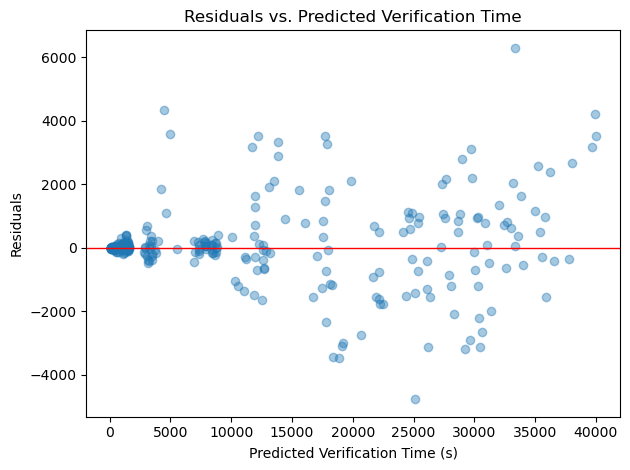

In [56]:
residuals = y_reg_test - y_reg_pred

plt.scatter(y_reg_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linewidth=1)
plt.xlabel('Predicted Verification Time (s)')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Verification Time')
plt.tight_layout()
plt.show()

### Predicted vs. Actual Plot

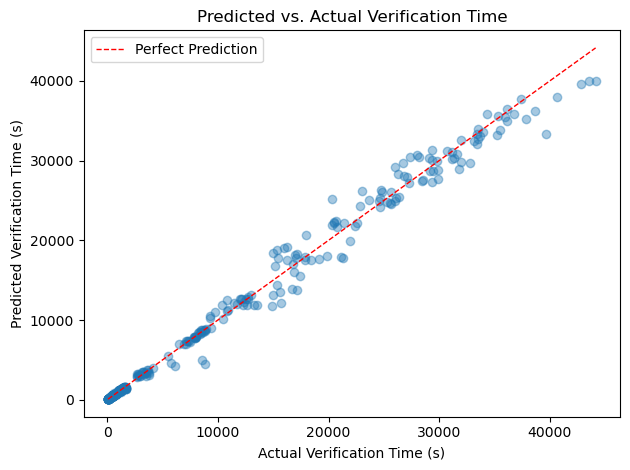

In [57]:
plt.scatter(y_reg_test, y_reg_pred, alpha=0.4)
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', linewidth=1, label='Perfect Prediction')
plt.xlabel('Actual Verification Time (s)')
plt.ylabel('Predicted Verification Time (s)')
plt.title('Predicted vs. Actual Verification Time')
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance

In [58]:
all_feature_names = list(X_reg.columns)

importances = reg_final_model.named_steps['model'].regressor_.feature_importances_

feature_importance = sorted(zip(importances, all_feature_names), key=lambda x: x[0], reverse=True)
print("Feature importances (Random Forest):")
for imp, name in feature_importance:
    print(f"{name}: {imp:.4f}")

Feature importances (Random Forest):
property.product: 0.4173
process.b1.capacity: 0.3920
property.winner: 0.0734
property.price: 0.0599
process.b4.capacity: 0.0494
process.b2.capacity: 0.0078
process.b3.capacity: 0.0001


## Saving the Final Model

In [ ]:
joblib.dump(reg_final_model, 'final_regression_model.joblib')
print('Model saved as final_regression_model.joblib')